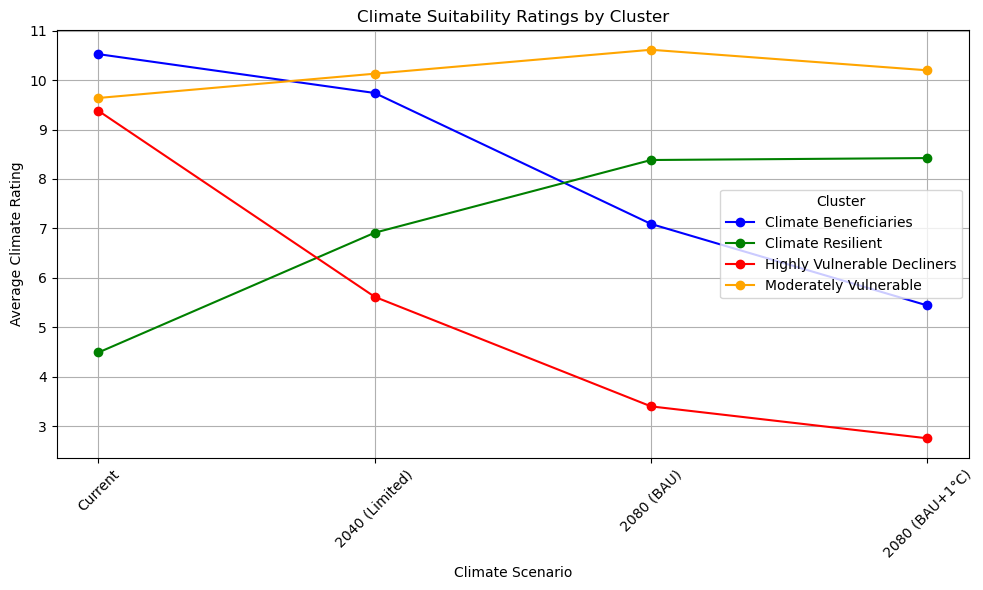

Top 10 genera in Highly Vulnerable Decliners cluster:
Genus
Rhododendron    41
Saxifraga       19
Primula         16
Veronica        15
Geranium        14
Dianthus        14
Sorbus          13
Salix           11
Sempervivum     11
Ribes           10
Name: count, dtype: int64


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Load the data
data = pd.read_csv('data/2025-03-22_test_set.csv')

# Select the relevant columns for clustering
ratings_columns = [
    'climate_rating_current_sheet',
    'climate_rating_emissions_limited_2040',
    'climate_rating_business_as_usual_2080',
    'climate_rating_bau_plus_1degree_2080'
]
ratings_data = data[ratings_columns]

# Impute missing values with the mean
imputer = SimpleImputer(strategy='mean')
imputed_data = imputer.fit_transform(ratings_data)

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(imputed_data)

# Apply K-means clustering
kmeans = KMeans(n_clusters=4, random_state=42)
data['Cluster'] = kmeans.fit_predict(scaled_data)

# Corrected mapping of clusters to descriptive names
cluster_labels = {
    0: 'Climate Resilient',
    1: 'Moderately Vulnerable',
    2: 'Highly Vulnerable Decliners',
    3: 'Climate Beneficiaries'
}
data['Cluster_Description'] = data['Cluster'].map(cluster_labels)

# Visualize the clusters with custom colors
colors = {
    'Highly Vulnerable Decliners': 'red',
    'Moderately Vulnerable': 'orange',
    'Climate Resilient': 'green',
    'Climate Beneficiaries': 'blue'
}

cluster_means = data.groupby('Cluster_Description')[ratings_columns].mean().T
ax = cluster_means.plot(marker='o', figsize=(10, 6), color=[colors[desc] for desc in cluster_means.columns])

plt.title('Climate Suitability Ratings by Cluster')
plt.xlabel('Climate Scenario')
plt.ylabel('Average Climate Rating')
plt.xticks(ticks=range(len(ratings_columns)), labels=['Current', '2040 (Limited)', '2080 (BAU)', '2080 (BAU+1°C)'], rotation=45)
plt.grid(True)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# Generate nomenclature statistics for Cluster 3 (Highly Vulnerable Decliners)
cluster_3_stats = data[data['Cluster_Description'] == 'Highly Vulnerable Decliners']['Genus'].value_counts().head(10)
print("Top 10 genera in Highly Vulnerable Decliners cluster:")
print(cluster_3_stats)

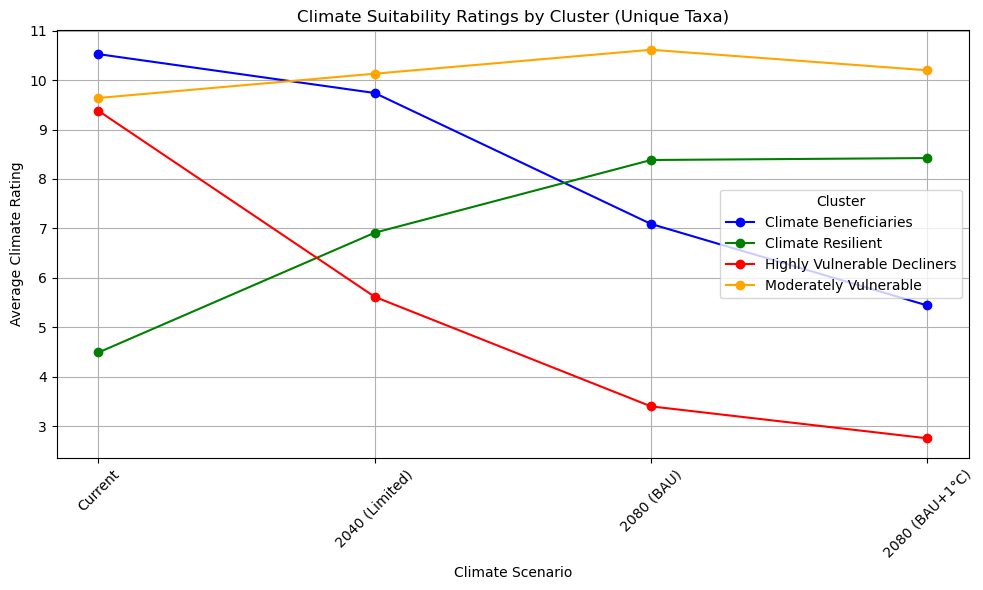

Genus
Rhododendron    41
Saxifraga       19
Primula         16
Veronica        15
Geranium        14
Dianthus        14
Sorbus          13
Salix           11
Sempervivum     11
Ribes           10
Name: count, dtype: int64

In [2]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# Remove duplicates based on GenusSpecies
unique_taxa_data = data.drop_duplicates(subset='GenusSpecies').copy()

# Columns for clustering
ratings_columns = [
    'climate_rating_current_sheet',
    'climate_rating_emissions_limited_2040',
    'climate_rating_business_as_usual_2080',
    'climate_rating_bau_plus_1degree_2080'
]

# Prepare data for clustering
ratings_data = unique_taxa_data[ratings_columns]

# Impute missing values with mean
imputer = SimpleImputer(strategy='mean')
imputed_data = imputer.fit_transform(ratings_data)

# Standardize data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(imputed_data)

# Apply K-means clustering with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
unique_taxa_data['Cluster'] = kmeans.fit_predict(scaled_data)

# Map clusters to descriptive labels
cluster_labels = {
    0: 'Climate Resilient',
    1: 'Moderately Vulnerable',
    2: 'Highly Vulnerable Decliners',
    3: 'Climate Beneficiaries'
}
unique_taxa_data['Cluster_Description'] = unique_taxa_data['Cluster'].map(cluster_labels)

# Visualize the clusters with custom colors
colors = {
    'Highly Vulnerable Decliners': 'red',
    'Moderately Vulnerable': 'orange',
    'Climate Resilient': 'green',
    'Climate Beneficiaries': 'blue'
}

cluster_means = unique_taxa_data.groupby('Cluster_Description')[ratings_columns].mean().T
ax = cluster_means.plot(marker='o', figsize=(10, 6), color=[colors[desc] for desc in cluster_means.columns])

plt.title('Climate Suitability Ratings by Cluster (Unique Taxa)')
plt.xlabel('Climate Scenario')
plt.ylabel('Average Climate Rating')
plt.xticks(ticks=range(len(ratings_columns)), labels=['Current', '2040 (Limited)', '2080 (BAU)', '2080 (BAU+1°C)'], rotation=45)
plt.grid(True)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# Display top 10 genera in the Highly Vulnerable Decliners cluster
cluster_3_stats = unique_taxa_data[unique_taxa_data['Cluster_Description'] == 'Highly Vulnerable Decliners']['Genus'].value_counts().head(10)
cluster_3_stats


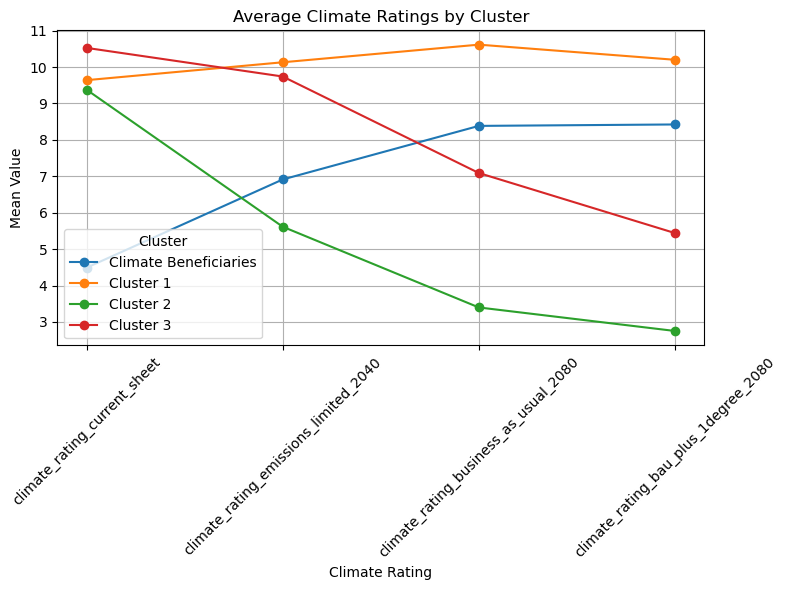


Number of samples per cluster:
 Cluster_Description
Cluster 3                1947
Cluster 1                1272
Cluster 2                 797
Climate Beneficiaries     229
Name: count, dtype: int64


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# -----------------------
# Step 1: Load the data
# -----------------------

# Replace with your CSV filename/path
csv_file = 'data/2025-03-22_test_set.csv'

# Read the CSV into a DataFrame
# Adjust if needed (engine, nrows, etc.)
data = pd.read_csv(csv_file)

# ----------------------------------------------
# Step 2: Select the relevant columns
# ----------------------------------------------

ratings_columns = [
    'climate_rating_current_sheet',
    'climate_rating_emissions_limited_2040',
    'climate_rating_business_as_usual_2080',
    'climate_rating_bau_plus_1degree_2080'
]

# Filter out rows that do not have these columns
ratings_data = data[ratings_columns]

# -------------------------------------------------------
# Step 3: Handle missing values (impute with the mean)
# -------------------------------------------------------

imputer = SimpleImputer(strategy='mean')
imputed_data = imputer.fit_transform(ratings_data)

# --------------------------------------------------------
# Step 4: Standardize the data
# --------------------------------------------------------

scaler = StandardScaler()
scaled_data = scaler.fit_transform(imputed_data)

# --------------------------------------------------------
# Step 5: Apply K-Means clustering
# --------------------------------------------------------

kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_data)

data['Cluster'] = cluster_labels

# Map each cluster numeric code to a descriptive name
label_map = {
    0: 'Climate Beneficiaries',
    1: 'Cluster 1',
    2: 'Cluster 2',
    3: 'Cluster 3'
}

data['Cluster_Description'] = data['Cluster'].map(label_map)

# --------------------------------------------------------
# Step 6: Calculate the mean rating per cluster
# --------------------------------------------------------

cluster_means = data.groupby('Cluster_Description')[ratings_columns].mean()

# --------------------------------------------------------
# Step 7: Visualize cluster means with a simple line plot
# --------------------------------------------------------

# Each cluster will be a separate line
plt.figure(figsize=(8, 6))

for cluster_name in cluster_means.index:
    # Extract the mean ratings for the cluster_name
    row = cluster_means.loc[cluster_name, ratings_columns]

    # Plot the means across the four rating columns
    plt.plot(ratings_columns, row, marker='o', label=cluster_name)

plt.title('Average Climate Ratings by Cluster')
plt.xlabel('Climate Rating')
plt.ylabel('Mean Value')
plt.legend(title='Cluster')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

# --------------------------------------------------------
# Step 8: Optional - Inspect cluster distribution
# --------------------------------------------------------

print("\nNumber of samples per cluster:\n", data['Cluster_Description'].value_counts())


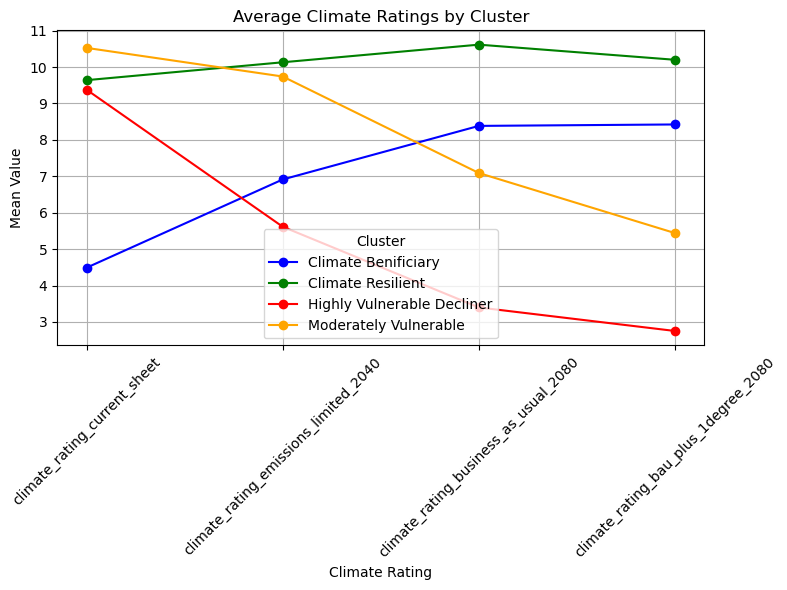


Number of samples per cluster:
 Cluster_Description
Moderately Vulnerable         1947
Climate Resilient             1272
Highly Vulnerable Decliner     797
Climate Benificiary            229
Name: count, dtype: int64

Top 10 'GenusSpecies' in Climate Resilient cluster:
 7                    Abies pinsapo
8                Abies chensiensis
9                      Abies fabri
12                  Abies delavayi
25              Acaena myriophylla
28    Acantholimon caryophyllaceum
30                 Acanthus sennii
34                Acer pauciflorum
35                   Acer palmatum
41             Acer crataegifolium
Name: GenusSpecies, dtype: object

Top 10 'GenusSpecies' in Highly Vulnerable Decliner cluster:
 0     Abeliophyllum distichum
1               Abies koreana
2              Abies balsamea
3            Abies lasiocarpa
6              Abies amabilis
18              Abies procera
24         Acaena magellanica
26         Acaena microphylla
27      Acantholimon ulicinum
40        

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# -----------------------
# Step 1: Load the data
# -----------------------

# Replace with your CSV filename/path
csv_file = 'data/2025-03-22_test_set.csv'

# Read the CSV into a DataFrame
# Adjust if needed (engine, nrows, etc.)
data = pd.read_csv(csv_file)

# ----------------------------------------------
# Step 2: Select the relevant columns
# ----------------------------------------------

ratings_columns = [
    'climate_rating_current_sheet',
    'climate_rating_emissions_limited_2040',
    'climate_rating_business_as_usual_2080',
    'climate_rating_bau_plus_1degree_2080'
]

# Filter out rows that do not have these columns
ratings_data = data[ratings_columns]

# -------------------------------------------------------
# Step 3: Handle missing values (impute with the mean)
# -------------------------------------------------------

imputer = SimpleImputer(strategy='mean')
imputed_data = imputer.fit_transform(ratings_data)

# --------------------------------------------------------
# Step 4: Standardize the data
# --------------------------------------------------------

scaler = StandardScaler()
scaled_data = scaler.fit_transform(imputed_data)

# --------------------------------------------------------
# Step 5: Apply K-Means clustering
# --------------------------------------------------------

kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_data)

data['Cluster'] = cluster_labels

# Map each cluster numeric code to a descriptive name
label_map = {
    0: 'Climate Benificiary',
    1: 'Climate Resilient',
    2: 'Highly Vulnerable Decliner',
    3: 'Moderately Vulnerable'
}

data['Cluster_Description'] = data['Cluster'].map(label_map)

# --------------------------------------------------------
# Step 6: Calculate the mean rating per cluster
# --------------------------------------------------------

cluster_means = data.groupby('Cluster_Description')[ratings_columns].mean()

# --------------------------------------------------------
# Step 7: Visualize cluster means with a simple line plot
# --------------------------------------------------------

plt.figure(figsize=(8, 6))

color_map = {
    'Climate Benificiary': 'blue',
    'Climate Resilient': 'green',
    'Highly Vulnerable Decliner': 'red',
    'Moderately Vulnerable': 'orange'
}

for cluster_name in cluster_means.index:
    # Extract the mean ratings for the cluster_name
    row = cluster_means.loc[cluster_name, ratings_columns]
    # Plot the means across the four rating columns
    plt.plot(ratings_columns, row, marker='o', label=cluster_name, color=color_map[cluster_name])

plt.title('Average Climate Ratings by Cluster')
plt.xlabel('Climate Rating')
plt.ylabel('Mean Value')
plt.legend(title='Cluster')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

# --------------------------------------------------------
# Step 8: Optional - Inspect cluster distribution
# --------------------------------------------------------

print("\nNumber of samples per cluster:\n", data['Cluster_Description'].value_counts())

# --------------------------------------------------------
# Step 9: Print top 10 'GenusSpecies' from two clusters
# --------------------------------------------------------

# We assume a column named 'GenusSpecies' exists.

# Print top 10 from the 'Climate Resilient' cluster
resilient_cluster = data[data['Cluster_Description'] == 'Climate Resilient'].head(10)
print("\nTop 10 'GenusSpecies' in Climate Resilient cluster:\n", resilient_cluster['GenusSpecies'])

# Print top 10 from the 'Highly Vulnerable Decliner' cluster
decliner_cluster = data[data['Cluster_Description'] == 'Highly Vulnerable Decliner'].head(10)
print("\nTop 10 'GenusSpecies' in Highly Vulnerable Decliner cluster:\n", decliner_cluster['GenusSpecies'])


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import StandardScaler  # <-- Possibly skip
from kmodes.kmodes import KModes

csv_file = 'data/2025-03-22_test_set.csv'
data = pd.read_csv(csv_file)

# Columns of interest
ratings_columns = [
    'climate_rating_current_sheet',
    'climate_rating_emissions_limited_2040',
    'climate_rating_business_as_usual_2080',
    'climate_rating_bau_plus_1degree_2080'
]

# Filter & impute
ratings_data = data[ratings_columns]
imputer = SimpleImputer(strategy='mean')
imputed_data = imputer.fit_transform(ratings_data)

# If you treat them as numeric ordinal data, you may skip standard scaling.

# K-Modes for 4 clusters
km = KModes(n_clusters=4, init='Cao', n_init=5, random_state=42)
cluster_labels = km.fit_predict(imputed_data)

data['Cluster'] = cluster_labels

# Rename your clusters as desired
label_map = {
    0: 'Climate Benificiary',
    1: 'Climate Resilient',
    2: 'Highly Vulnerable Decliner',
    3: 'Moderately Vulnerable'
}
data['Cluster_Description'] = data['Cluster'].map(label_map)

# Group and look at “means” (which is numeric average, though data is ordinal)
cluster_means = data.groupby('Cluster_Description')[ratings_columns].mean()

# Plot
plt.figure(figsize=(8, 6))
color_map = {
    'Climate Benificiary': 'blue',
    'Climate Resilient': 'green',
    'Highly Vulnerable Decliner': 'red',
    'Moderately Vulnerable': 'orange'
}
for cluster_name in cluster_means.index:
    row = cluster_means.loc[cluster_name, ratings_columns]
    plt.plot(ratings_columns, row, marker='o', label=cluster_name, color=color_map[cluster_name])

plt.title('Average Climate Ratings by Cluster (K-Modes)')
plt.xlabel('Climate Rating')
plt.ylabel('Mean Value')
plt.legend(title='Cluster')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()


ModuleNotFoundError: No module named 'kmodes'

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
import json

# Custom JSON encoder to handle NumPy types
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

# Read the CSV file
df = pd.read_csv('data/2025-03-22_test_set.csv')

# Select climate rating columns as primary features
climate_columns = [
    'climate_rating_current_sheet', 
    'climate_rating_emissions_limited_2040', 
    'climate_rating_business_as_usual_2080', 
    'climate_rating_bau_plus_1degree_2080'
]

# Additional contextual features to consider
contextual_columns = [
    'Family', 
    'Genus', 
    'ProvenanceCode', 
    'IUCNRedList', 
    'NationalRedList', 
    'RegionalRedList'
]

# Prepare data for clustering
# Encode categorical columns
le = LabelEncoder()
for col in contextual_columns:
    df[col + '_encoded'] = le.fit_transform(df[col].astype(str).fillna('Unknown'))

# Combine features
feature_columns = climate_columns + [col + '_encoded' for col in contextual_columns]

# Prepare feature matrix
X = df[feature_columns]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform K-means clustering
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Cluster names with a focus on climate trajectory
cluster_names = {
    0: 'Climate Beneficiary',
    1: 'Climate Resilient',
    2: 'Highly Vulnerable Decliner',
    3: 'Moderately Vulnerable'
}

# Add cluster names to the dataframe
df['ClusterName'] = df['Cluster'].map(cluster_names)

# Detailed Cluster Analysis
cluster_analysis = {}

# For each cluster
for cluster_num in range(n_clusters):
    cluster_name = cluster_names[cluster_num]
    cluster_data = df[df['Cluster'] == cluster_num]
    
    # Prepare cluster analysis dictionary
    cluster_analysis[cluster_name] = {
        'samples': [],
        'statistics': {},
        'composition': {}
    }
    
    # Collect samples (up to 10)
    samples = cluster_data.sample(min(10, len(cluster_data)))
    
    # Prepare samples
    for _, sample in samples.iterrows():
        cluster_analysis[cluster_name]['samples'].append({
            'GenusSpecies': sample['GenusSpecies'],
            'LocationName': sample['LocationName'],
            'ItemLocationCode': sample['ItemLocationCode'],
            'LifeForm': sample['LifeForm'],
            **{col: float(sample[col]) for col in climate_columns}
        })
    
    # Calculate statistics for climate rating columns
    for col in climate_columns:
        cluster_analysis[cluster_name]['statistics'][col] = {
            'mean': float(cluster_data[col].mean()),
            'min': float(cluster_data[col].min()),
            'max': float(cluster_data[col].max()),
            'std': float(cluster_data[col].std())
        }
    
    # Cluster composition analysis
    # Breakdown of key categorical features
    composition_features = ['Family', 'Genus', 'LifeForm', 'ProvenanceCode']
    for feature in composition_features:
        cluster_analysis[cluster_name]['composition'][feature] = (
            cluster_data[feature].value_counts(normalize=True)
            .nlargest(5)
            .to_dict()
        )

# Calculate cluster centroids in original scale
cluster_centroids = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_centroid_analysis = {}
for i, centroid in enumerate(cluster_centroids):
    cluster_centroid_analysis[cluster_names[i]] = dict(
        zip(feature_columns, map(float, centroid))
    )

# Additional insights
print("Cluster Centroid Analysis:")
print(pd.DataFrame(cluster_centroid_analysis).T)

# Save detailed analysis using custom JSON encoder
with open('climate_cluster_analysis.json', 'w') as f:
    json.dump({
        'cluster_analysis': cluster_analysis,
        'cluster_centroids': cluster_centroid_analysis
    }, f, indent=2, cls=NumpyEncoder)

# Save clustered data
df.to_csv('botanical_garden_clustered_data.csv', index=False)

print("\nAnalysis complete. Results saved to climate_cluster_analysis.json and botanical_garden_clustered_data.csv")

Cluster Centroid Analysis:
                            climate_rating_current_sheet  \
Climate Beneficiary                            10.583862   
Climate Resilient                               9.075419   
Highly Vulnerable Decliner                     10.333333   
Moderately Vulnerable                           8.829060   

                            climate_rating_emissions_limited_2040  \
Climate Beneficiary                                      9.755213   
Climate Resilient                                        9.868715   
Highly Vulnerable Decliner                               8.894309   
Moderately Vulnerable                                    5.420024   

                            climate_rating_business_as_usual_2080  \
Climate Beneficiary                                      7.029012   
Climate Resilient                                       10.478352   
Highly Vulnerable Decliner                               7.243902   
Moderately Vulnerable                             